### Lat_depth EOF analysis

In [ ]:
#!/usr/bin/env python3
# ============================================================
# Combined EOF Analysis for CMIP6 ocean variables in (lat,depth)
# at fixed longitudes, INCLUDING South + North Atlantic
#
# Robust version:
#   • Uses "nearest longitude among VALID ocean points"
#   • Drops invalid rows
#   • Sorts by latitude
#   • Applies sqrt(cos(lat) * dz) weighting
#
# Output:
#   EOF(mode, lat, depth)
#   PC(member, time, mode)
#   variance_fraction(mode)
# ============================================================

import os
import glob
import re
import numpy as np
import xarray as xr
from eofs.standard import Eof
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================
MODEL   = "EC-Earth3"      # EC-Earth3, IPSL-CM6A-LR, CESM2, MPI-ESM1-2-LR
VAR     = "thetao"         # thetao or so
NMODES  = 10

START_YEAR = 1850
END_YEAR   = 2014

TARGET_LONS   = [-60.0, -40.0, -20.0, -10.0]
LON_WINDOW    = 10.0       # degrees
DEPTH_RANGE_M = (0.0, 5000.0)

# ============================================================
# DIRECTORIES
# ============================================================
if MODEL == "EC-Earth3":
    IN_DIR = f"/data/projects/nckf/frekle/CMIP6_data/EC-Earth3/{VAR}/regridded/"
elif MODEL == "IPSL-CM6A-LR":
    IN_DIR = f"/data/projects/nckf/frekle/CMIP6_data/IPSL-CM6A-LR/{VAR}/masked/"
elif MODEL == "CESM2":
    IN_DIR = f"/data/projects/nckf/frekle/CMIP6_data/CESM2/{VAR}/masked/"
elif MODEL == "MPI-ESM1-2-LR":
    IN_DIR = f"/data/projects/nckf/frekle/CMIP6_data/MPI-ESM1-2-LR/{VAR}/masked/"
else:
    raise ValueError("Unknown MODEL")

OUT_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
os.makedirs(OUT_DIR, exist_ok=True)

# ============================================================
# UTILITIES
# ============================================================

def parse_member_label(path):
    m = re.search(r"_(r\d+i\d+p\d+f\d+)", os.path.basename(path))
    return m.group(1) if m else os.path.basename(path)

def wrap_lon(lon):
    return ((lon + 180) % 360) - 180

def standardize_latlon(ds):
    lat_var = next(v for v in ["lat", "latitude", "nav_lat"] if v in ds)
    lon_var = next(v for v in ["lon", "longitude", "nav_lon"] if v in ds)

    lat = ds[lat_var]
    lon = ds[lon_var]

    if lat.ndim == 1 and lon.ndim == 1:
        lon2d, lat2d = np.meshgrid(lon.values, lat.values)
        ds = ds.drop_vars([lat_var, lon_var])
        ds = ds.rename_dims({lat.dims[0]: "y", lon.dims[0]: "x"})
        ds["lat2d"] = xr.DataArray(lat2d, dims=("y", "x"))
        ds["lon2d"] = xr.DataArray(lon2d, dims=("y", "x"))
        return ds

    ds = ds.swap_dims({lat.dims[0]: "y", lat.dims[1]: "x"})
    ds = ds.rename({lat_var: "lat2d", lon_var: "lon2d"})
    return ds

def get_depth_dim_and_coord(da, ds):
    if "olevel" in da.dims:
        return "olevel", ds["olevel"].values
    if "depth" in da.dims:
        return "depth", ds["depth"].values
    if "lev" in da.dims:
        z = ds["lev"].values
        if np.nanmax(z) > 10000:
            z = z / 100.0
        return "lev", z
    raise KeyError("No vertical coordinate found")

def compute_layer_thickness(z):
    z = np.asarray(z)
    dz = np.empty_like(z, dtype=float)
    dz[1:-1] = 0.5 * (z[2:] - z[:-2])
    dz[0]    = z[1] - z[0]
    dz[-1]   = z[-1] - z[-2]
    return np.abs(dz)

def extract_section_valid_ocean(da, ds, target_lon, depth_dim):
    lon2d = ds["lon2d"].values
    lat2d = ds["lat2d"].values

    lonW = wrap_lon(lon2d)
    tW   = wrap_lon(target_lon)

    valid_xy = np.isfinite(da).any(dim=("time", depth_dim)).values
    ny, nx = lonW.shape

    ix = np.full(ny, -1, dtype=int)

    for y in range(ny):
        cand = np.where(valid_xy[y])[0]
        if cand.size == 0:
            continue

        d = np.abs(lonW[y, cand] - tW)
        ok = d <= LON_WINDOW
        if not np.any(ok):
            continue

        cand = cand[ok]
        d    = d[ok]
        ix[y] = cand[np.argmin(d)]

    valid_row = ix >= 0

    sec = da.isel(x=xr.DataArray(np.where(valid_row, ix, 0), dims="y"))
    sec = sec.where(xr.DataArray(valid_row, dims="y"))

    lat_1d = np.where(valid_row, lat2d[np.arange(ny), ix], np.nan)

    return sec, lat_1d, valid_row

# ============================================================
# MAIN WORKFLOW
# ============================================================

def run_longitude(target_lon):

    print("\n" + "="*80)
    print(f"▶ Longitude {target_lon:.1f}° | MODEL={MODEL} | VAR={VAR}")
    print("="*80)

    files = sorted(glob.glob(os.path.join(IN_DIR, f"*{VAR}*_masked*.nc")))
    if not files:
        raise FileNotFoundError("No masked files found")

    sections = []
    member_labels = []

    lat_ref = z_ref = dz_ref = depth_dim_ref = None

    for i, f in enumerate(files, start=1):
        label = parse_member_label(f)
        member_labels.append(label)

        print(f"\n  → Member {i}/{len(files)}: {label}")

        ds = standardize_latlon(xr.open_dataset(f))
        da = ds[VAR]

        depth_dim, z = get_depth_dim_and_coord(da, ds)
        dz = compute_layer_thickness(z)

        da = da.sel(time=slice(f"{START_YEAR}-01-01", f"{END_YEAR}-12-31"))

        sec, lat1d, valid = extract_section_valid_ocean(
            da, ds, target_lon, depth_dim
        )

        keepz = (z >= DEPTH_RANGE_M[0]) & (z <= DEPTH_RANGE_M[1])
        sec = sec.isel({depth_dim: keepz})
        z_sel  = z[keepz]
        dz_sel = dz[keepz]

        good = np.isfinite(lat1d)
        sec = sec.isel(y=good)
        lat1d = lat1d[good]

        order = np.argsort(lat1d)
        sec = sec.isel(y=order)
        lat1d = lat1d[order]

        sec = sec - sec.mean("time")
        sec = sec.expand_dims(member=[label])
        sections.append(sec)

        if lat_ref is None:
            lat_ref = lat1d
            z_ref   = z_sel
            dz_ref  = dz_sel
            depth_dim_ref = depth_dim

        print(f"    Kept latitude rows: {lat1d.size}")

    print("\n▶ Aligning time across members")
    common_time = sections[0]["time"].values
    for s in sections[1:]:
        common_time = np.intersect1d(common_time, s["time"].values)

    combined = xr.concat([s.sel(time=common_time) for s in sections], dim="member")

    # SAFE renaming: avoid 'lat' name collision
    combined = combined.rename({
        "y": "lat_index",
        depth_dim_ref: "depth"
    })

    combined = combined.assign_coords(
        lat=("lat_index", lat_ref),
        depth=("depth", z_ref),
    )

    n_member = combined.sizes["member"]
    n_time   = combined.sizes["time"]
    n_lat    = combined.sizes["lat_index"]
    n_depth  = combined.sizes["depth"]

    print(f"\n▶ Combined shape: member={n_member}, time={n_time}, lat={n_lat}, depth={n_depth}")

    data = combined.transpose("member", "time", "lat_index", "depth").values
    data2d = data.reshape(n_member * n_time, n_lat * n_depth)
    data2d = np.ma.masked_invalid(data2d)

    print("▶ Computing EOF weights")
    w_lat = np.clip(np.cos(np.deg2rad(lat_ref)), 0, None)
    w2d   = np.sqrt(w_lat[:, None] * dz_ref[None, :])
    weights = w2d.reshape(n_lat * n_depth)

    print("▶ Solving EOFs")
    solver = Eof(data2d, weights=weights)

    EOFs = solver.eofs(neofs=NMODES).reshape(NMODES, n_lat, n_depth)
    PCs  = solver.pcs(npcs=NMODES).reshape(n_member, n_time, NMODES)
    VF   = solver.varianceFraction()[:NMODES]

    tag = f"{abs(target_lon):04.1f}".replace(".", "p")
    hemi = "W" if target_lon < 0 else "E"
    outfile = os.path.join(OUT_DIR, f"EOF_latdepth_{VAR}_{hemi}{tag}.nc")

    print(f"▶ Writing {outfile}")

    xr.Dataset(
        {
            "EOF": (("mode", "lat_index", "depth"), EOFs),
            "PC":  (("member", "time", "mode"), PCs),
            "variance_fraction": (("mode",), VF),
        },
        coords={
            "mode": np.arange(1, NMODES + 1),
            "member": np.array(member_labels, dtype=object),
            "time": common_time,
            "lat": ("lat_index", lat_ref),
            "depth": ("depth", z_ref),
        },
        attrs={
            "MODEL": MODEL,
            "VAR": VAR,
            "TARGET_LON_DEG": target_lon,
            "LON_WINDOW_DEG": LON_WINDOW,
            "WEIGHTING": "sqrt(cos(lat) * dz)",
            "DEPTH_RANGE_M": f"{DEPTH_RANGE_M[0]}-{DEPTH_RANGE_M[1]}",
        }
    ).to_netcdf(outfile)

    print(f"✓ Done longitude {target_lon:.1f}°")

# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    print(f"\n=== MODEL={MODEL} | VAR={VAR} ===")
    print(f"TARGET_LONS={TARGET_LONS}")
    print(f"LON_WINDOW={LON_WINDOW} deg")
    print(f"DEPTH_RANGE_M={DEPTH_RANGE_M}")

    for lon in TARGET_LONS:
        run_longitude(lon)

    print("\n✅ All longitudes processed successfully.")


### Lag matrix

In [ ]:
#!/usr/bin/env python3
# ============================================================
# TOP MEMBERS × TOP MODES (LAT–DEPTH EOF × AMOC)
#
# Lag convention:
#   lag > 0  → EOF leads AMOC
#   lag < 0  → AMOC leads EOF
#
# Runs independently for each longitude section
# ============================================================

import xarray as xr
import numpy as np
import cftime
import glob
import os
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# USER CONFIG
# ============================================================
MODEL = "CESM2"   # "MPI-ESM1-2-LR", "IPSL-CM6A-LR", "CESM2", "EC-Earth3"
VAR   = "thetao"

EOF_DIR  = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

AMOC_VARS = {
    "26N": "AMOC_26N_member",
    "45N": "AMOC_45N_member",
}

MAX_LAG = 50
NTOP_MEMBERS = 5
NTOP_MODES   = 5

# ============================================================
# HELPER: ROBUST YEAR EXTRACTION
# ============================================================
def extract_years(time_da, reference_years=None):
    vals = time_da.values

    if np.issubdtype(vals.dtype, np.datetime64):
        return np.array(
            [v.astype("datetime64[Y]").astype(int) + 1970 for v in vals]
        )

    if hasattr(vals[0], "year"):
        return np.array([v.year for v in vals])

    if "units" in time_da.attrs:
        dates = cftime.num2date(
            vals,
            units=time_da.attrs["units"],
            calendar=time_da.attrs.get("calendar", "standard")
        )
        return np.array([d.year for d in dates])

    if reference_years is None:
        raise ValueError("Index-based time but no reference_years provided")

    return reference_years


# ============================================================
# CORRELATION ROUTINES
# ============================================================
def corr_1d(x, y):
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()

    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]
    y = y[ok]

    if x.size < 3:
        return np.nan
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan

    return np.corrcoef(x, y)[0, 1]


def best_lag_corr(x, y, max_lag):
    best_c = np.nan
    best_L = 0

    for L in range(-max_lag, max_lag + 1):
        if L < 0:
            c = corr_1d(x[-L:], y[:L])
        elif L > 0:
            c = corr_1d(x[:-L], y[L:])
        else:
            c = corr_1d(x, y)

        if np.isfinite(c) and (
            not np.isfinite(best_c) or abs(c) > abs(best_c)
        ):
            best_c = c
            best_L = L

    return best_c, best_L


# ============================================================
# LOAD AMOC ONCE
# ============================================================
print("\nLoading AMOC...")
ds_amoc = xr.decode_cf(xr.open_dataset(AMOC_FILE))

# ============================================================
# LOOP OVER LONGITUDES
# ============================================================
eof_files = sorted(glob.glob(os.path.join(EOF_DIR, f"EOF_latdepth_{VAR}_*.nc")))
if not eof_files:
    raise FileNotFoundError(f"No lat–depth EOF files found in {EOF_DIR}")

print(f"\nFound {len(eof_files)} longitude sections")

for eof_file in eof_files:

    tag = os.path.basename(eof_file).replace(".nc", "")
    print("\n" + "="*80)
    print(f"Processing: {tag}")
    print("="*80)

    # ------------------------
    # Load EOF PCs
    # ------------------------
    ds_eof = xr.decode_cf(xr.open_dataset(eof_file))
    PC = ds_eof["PC"]   # (member, time, mode)

    if "member" not in PC.dims:
        raise ValueError("PC must have member dimension")

    # Extract years from EOF PCs (these are the authoritative years)
    PC_years = extract_years(PC["time"])

    # Extract AMOC years using PC years as reference
    AMOC_years = extract_years(
        ds_amoc["time"],
        reference_years=PC_years
    )

    # ------------------------
    # Align time
    # ------------------------
    common_years = np.intersect1d(PC_years, AMOC_years)
    if common_years.size == 0:
        raise RuntimeError("No overlapping years with AMOC")

    PC = PC.isel(time=np.isin(PC_years, common_years))
    ds_amoc_sel = ds_amoc.isel(time=np.isin(AMOC_years, common_years))

    print(
        f"Aligned on {len(common_years)} years: "
        f"{common_years[0]}–{common_years[-1]}"
    )

    NMODES  = PC.sizes["mode"]
    NMEMBER = PC.sizes["member"]

    # ============================================================
    # MAIN ANALYSIS
    # ============================================================
    for latlabel, amocvar in AMOC_VARS.items():

        print("\n------------------------------------------------")
        print(f" AMOC {latlabel} | {tag}")
        print("------------------------------------------------")

        member_summaries = []

        # ---------- Step 1: best mode per member ----------
        for mem in range(NMEMBER):
            pc_mem   = PC.isel(member=mem)
            amoc_mem = ds_amoc_sel[amocvar].isel(member=mem)

            best_corr = np.nan
            best_mode = None
            best_lag  = None

            y = amoc_mem.values

            for m in range(NMODES):
                x = pc_mem.isel(mode=m).values
                c, L = best_lag_corr(x, y, MAX_LAG)

                if np.isfinite(c) and (
                    not np.isfinite(best_corr) or abs(c) > abs(best_corr)
                ):
                    best_corr = c
                    best_mode = m
                    best_lag  = L

            if best_mode is not None:
                member_summaries.append({
                    "member": mem,
                    "best_corr": best_corr,
                    "best_mode": best_mode,
                    "best_lag":  best_lag,
                })

        # ---------- Step 2: select top members ----------
        member_summaries = sorted(
            member_summaries,
            key=lambda r: abs(r["best_corr"]),
            reverse=True
        )[:NTOP_MEMBERS]

        # ---------- Step 3: print top modes ----------
        for r in member_summaries:
            mem = r["member"]
            print(
                f"\nMember {mem}  (best mode {r['best_mode']}, "
                f"corr={r['best_corr']:+.3f}, lag={r['best_lag']:+d} yr)"
            )

            pc_mem   = PC.isel(member=mem)
            amoc_mem = ds_amoc_sel[amocvar].isel(member=mem)

            corr = np.full(NMODES, np.nan)
            lag  = np.full(NMODES, np.nan)

            y = amoc_mem.values
            for m in range(NMODES):
                x = pc_mem.isel(mode=m).values
                corr[m], lag[m] = best_lag_corr(x, y, MAX_LAG)

            ranked = np.argsort(np.abs(corr))[::-1]

            print("Rank | Mode | Corr | Lag (yr)")
            count = 0
            for m in ranked:
                if np.isfinite(corr[m]):
                    count += 1
                    print(
                        f"{count:>4d} | "
                        f"{m:>4d} | "
                        f"{corr[m]:+7.3f} | "
                        f"{int(lag[m]):>7d}"
                    )
                if count == NTOP_MODES:
                    break

print("\n✅ Lag-correlation analysis complete for all longitudes.")


In [ ]:
#!/usr/bin/env python3
# ============================================================
# PC–AMOC LAG MATRIX (LAT–DEPTH EOF VERSION)
#
# Computes lagged correlations between:
#   • EOF PCs (ensemble mean)
#   • AMOC at 26°N and 45°N
#
# Lag convention:
#   lag > 0  → PC leads AMOC
#   lag < 0  → AMOC leads PC
# ============================================================

import xarray as xr
import numpy as np

# ============================================================
# CONFIG
# ============================================================

MODEL = "IPSL-CM6A-LR"   # "CESM2", "IPSL-CM6A-LR", "MPI-ESM1-2-LR"
VAR   = "thetao"

EOF_FILE = (
    f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
    f"EOF_latdepth_{VAR}_W30p0.nc"
)

AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

MAX_LAG = 50
modes_to_use = slice(None)   # e.g. slice(0,5)

OUTFILE = (
    f"/data/users/frekle/AMOC_analysis/Lag_plots/{MODEL}/Lat_depth/"
    f"lag_matrix_PC_AMOC_{MODEL}_{VAR}_latdepth30W.nc"
)

# ============================================================
# HELPERS
# ============================================================

def get_1d_time_series(da, name):
    """Force DataArray to (time,)"""
    if "member" in da.dims:
        da = da.mean("member")
    da = da.squeeze()
    if da.ndim != 1:
        raise ValueError(f"{name} must be 1D after squeeze, got {da.dims}")
    return np.asarray(da.values, dtype=float)


def corr_pearson(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 3:
        return np.nan
    a = a[mask] - a[mask].mean()
    b = b[mask] - b[mask].mean()
    return float(np.dot(a, b) / np.sqrt(np.dot(a, a) * np.dot(b, b)))


# ============================================================
# LOAD EOF PCs
# ============================================================

print("▶ Loading EOF dataset")
ds_eof = xr.open_dataset(EOF_FILE)
PC = ds_eof["PC"]     # (member, time, mode)

PC_mean = PC.mean("member").isel(mode=modes_to_use)
PC_array = PC_mean.values     # (time, mode)

ntime, nmodes = PC_array.shape
print(f"✔ EOF PCs loaded: time={ntime}, modes={nmodes}")

# ============================================================
# LOAD AMOC
# ============================================================

print("▶ Loading AMOC dataset")
ds_amoc = xr.open_dataset(AMOC_FILE)

amoc26 = get_1d_time_series(ds_amoc["AMOC_26N_ensmean"], "AMOC_26N_ensmean")
amoc45 = get_1d_time_series(ds_amoc["AMOC_45N_ensmean"], "AMOC_45N_ensmean")

if len(amoc26) != ntime:
    raise ValueError("Time mismatch between EOF PCs and AMOC")

print("✔ AMOC aligned with EOF time axis")

# ============================================================
# LAG MATRICES
# ============================================================

lags = np.arange(-MAX_LAG, MAX_LAG + 1)

lagcorr_26 = np.full((nmodes, len(lags)), np.nan)
lagcorr_45 = np.full((nmodes, len(lags)), np.nan)

print("\n▶ Computing lag correlations")

for m in range(nmodes):
    pc = PC_array[:, m]

    for i, L in enumerate(lags):
        if L < 0:
            lagcorr_26[m, i] = corr_pearson(pc[-L:], amoc26[:L])
            lagcorr_45[m, i] = corr_pearson(pc[-L:], amoc45[:L])
        elif L > 0:
            lagcorr_26[m, i] = corr_pearson(pc[:-L], amoc26[L:])
            lagcorr_45[m, i] = corr_pearson(pc[:-L], amoc45[L:])
        else:
            lagcorr_26[m, i] = corr_pearson(pc, amoc26)
            lagcorr_45[m, i] = corr_pearson(pc, amoc45)

print("✔ Lag computation complete")

# ============================================================
# SAVE
# ============================================================

xr.Dataset(
    {
        "lagcorr_AMOC_26N": (("mode", "lag"), lagcorr_26),
        "lagcorr_AMOC_45N": (("mode", "lag"), lagcorr_45),
    },
    coords={
        "mode": PC_mean["mode"],
        "lag": lags,
    },
    attrs={
        "MODEL": MODEL,
        "VAR": VAR,
        "EOF_TYPE": "lat-depth",
        "LAG_CONVENTION": "lag>0: PC leads AMOC",
    }
).to_netcdf(OUTFILE)

print("\n✅ Saved lag matrix to:")
print(OUTFILE)


/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
partially initialized module 'cartopy' has no attribute 'crs' (most likely due to a circular import)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


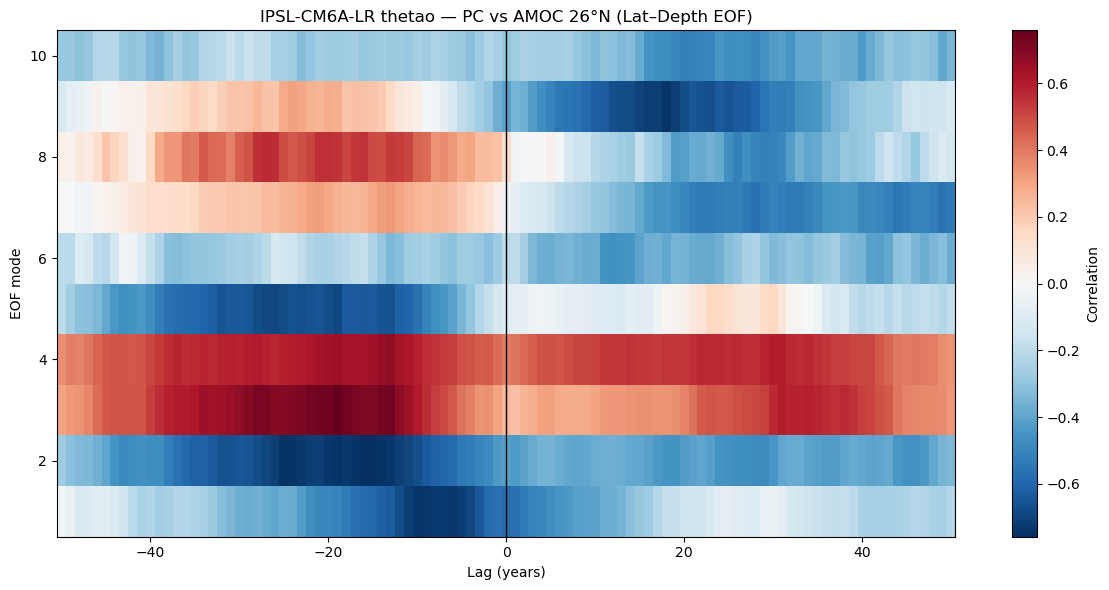

💾 Saved: /data/users/frekle/AMOC_analysis/Lag_plots/IPSL-CM6A-LR/Lat_depth/Figures/lag_matrix_AMOC_26N.png


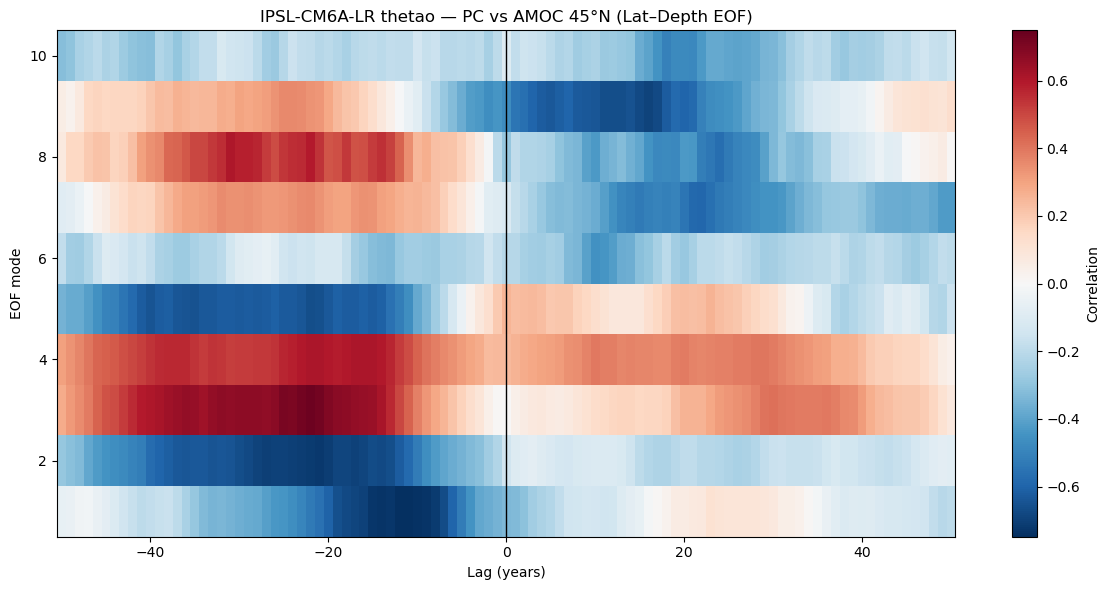

💾 Saved: /data/users/frekle/AMOC_analysis/Lag_plots/IPSL-CM6A-LR/Lat_depth/Figures/lag_matrix_AMOC_45N.png

✅ All figures created


In [2]:
#!/usr/bin/env python3
# ============================================================
# Plot PC–AMOC Lag Matrices (Lat–Depth EOFs)
# ============================================================

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os

# ============================================================
# CONFIG
# ============================================================

MODEL = "IPSL-CM6A-LR"
VAR   = "thetao"

INFILE = (
    f"/data/users/frekle/AMOC_analysis/Lag_plots/{MODEL}/Lat_depth/"
    f"lag_matrix_PC_AMOC_{MODEL}_{VAR}_latdepth30W.nc"
)

OUTDIR = f"/data/users/frekle/AMOC_analysis/Lag_plots/{MODEL}/Lat_depth/Figures"
os.makedirs(OUTDIR, exist_ok=True)

# ============================================================
# LOAD
# ============================================================

ds = xr.open_dataset(INFILE)

lags  = ds["lag"].values
modes = ds["mode"].values

data_26 = ds["lagcorr_AMOC_26N"].values
data_45 = ds["lagcorr_AMOC_45N"].values

# ============================================================
# PLOT FUNCTION
# ============================================================

def plot_lag_matrix(data, title, outfile):
    fig, ax = plt.subplots(figsize=(12, 6))

    vmax = np.nanmax(np.abs(data))

    pcm = ax.pcolormesh(
        lags,
        modes,
        data,
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
        shading="nearest"
    )

    ax.axvline(0, color="k", lw=1)
    ax.set_xlabel("Lag (years)")
    ax.set_ylabel("EOF mode")
    ax.set_title(title)

    cbar = plt.colorbar(pcm, ax=ax)
    cbar.set_label("Correlation")

    fig.tight_layout()
    # fig.savefig(outfile, dpi=150)
    plt.show(fig)

    print("💾 Saved:", outfile)

# ============================================================
# MAKE FIGURES
# ============================================================

plot_lag_matrix(
    data_26,
    f"{MODEL} {VAR} — PC vs AMOC 26°N (Lat–Depth EOF)",
    os.path.join(OUTDIR, "lag_matrix_AMOC_26N.png")
)

plot_lag_matrix(
    data_45,
    f"{MODEL} {VAR} — PC vs AMOC 45°N (Lat–Depth EOF)",
    os.path.join(OUTDIR, "lag_matrix_AMOC_45N.png")
)

print("\n✅ All figures created")


### Lag-1 autocorrelation

In [ ]:
#!/usr/bin/env python3
# ============================================================
# LAG-1 AUTOCORRELATION FOR EOF PCs AND AMOC (26N & 45N)
#
# Uses:
#   • EOF_latdepth_* files (PC(member,time,mode))
#   • AMOC_<MODEL>.nc with:
#       - AMOC_26N_ensmean(time)
#       - AMOC_45N_ensmean(time)
#
# Purpose:
#   Diagnose critical slowing down (tipping behavior)
# ============================================================

import numpy as np
import xarray as xr
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# USER CONFIG
# ============================================================

MODEL = "IPSL-CM6A-LR"          # CESM2, MPI-ESM1-2-LR, IPSL-CM6A-LR, EC-Earth3
VAR   = "thetao"         # thetao or so

EOF_FILE = (
    f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
    f"EOF_latdepth_{VAR}_W30p0.nc"
)

AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

MAX_LAG = 50
USE_ENSEMBLE_MEAN = True   # PCs averaged over members

# ============================================================
# UTILITIES
# ============================================================

def corr_pearson(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 3:
        return np.nan
    a = a[mask] - a[mask].mean()
    b = b[mask] - b[mask].mean()
    return float(np.dot(a, b) / np.sqrt(np.dot(a, a) * np.dot(b, b)))

# ============================================================
# LOAD EOF PCs
# ============================================================

print("\n▶ Loading EOF PCs")
ds_eof = xr.open_dataset(EOF_FILE)

PC = ds_eof["PC"]   # (member, time, mode)

if USE_ENSEMBLE_MEAN:
    PC = PC.mean("member")

ntime  = PC.sizes["time"]
nmodes = PC.sizes["mode"]

print(f"PC shape: time={ntime}, modes={nmodes}")

# ============================================================
# LOAD AMOC (26N & 45N)
# ============================================================

print("\n▶ Loading AMOC")
ds_amoc = xr.open_dataset(AMOC_FILE)

amoc26 = ds_amoc["AMOC_26N_ensmean"].values
amoc45 = ds_amoc["AMOC_45N_ensmean"].values

if len(amoc26) != ntime:
    raise ValueError("Time dimension mismatch between EOF PCs and AMOC")

# ============================================================
# COMPUTE PC AUTOCORRELATION
# ============================================================

lags = np.arange(MAX_LAG + 1)
acf_pc = np.zeros((nmodes, MAX_LAG + 1))

print("\n▶ Computing PC autocorrelation")

for m in range(nmodes):
    pc = PC.isel(mode=m).values
    for L in lags:
        acf_pc[m, L] = corr_pearson(pc[:-L or None], pc[L:])

# ============================================================
# COMPUTE AMOC AUTOCORRELATION
# ============================================================

acf_amoc26 = np.zeros(MAX_LAG + 1)
acf_amoc45 = np.zeros(MAX_LAG + 1)

print("▶ Computing AMOC autocorrelation")

for L in lags:
    acf_amoc26[L] = corr_pearson(amoc26[:-L or None], amoc26[L:])
    acf_amoc45[L] = corr_pearson(amoc45[:-L or None], amoc45[L:])

# ============================================================
# LAG-1 AUTOCORRELATION (KEY RESULT)
# ============================================================

lag1_pc   = acf_pc[:, 1]
lag1_26   = acf_amoc26[1]
lag1_45   = acf_amoc45[1]

print("\n=== LAG-1 AUTOCORRELATION ===")
for m, v in enumerate(lag1_pc, start=1):
    print(f"PC{m:02d}: {v:+.3f}")

print(f"\nAMOC 26N: {lag1_26:+.3f}")
print(f"AMOC 45N: {lag1_45:+.3f}")

# ============================================================
# SAVE OUTPUT
# ============================================================

OUTFILE = (
    f"/data/users/frekle/AMOC_analysis/Lag-1_autocorrelation/"
    f"lag1_autocorr_{MODEL}_{VAR}_26N_45N.nc"
)

xr.Dataset(
    {
        "acf_pc": (("mode", "lag"), acf_pc),
        "acf_amoc_26N": (("lag",), acf_amoc26),
        "acf_amoc_45N": (("lag",), acf_amoc45),
        "lag1_pc": (("mode",), lag1_pc),
        "lag1_amoc_26N": lag1_26,
        "lag1_amoc_45N": lag1_45,
    },
    coords={
        "mode": PC["mode"],
        "lag": lags,
    },
    attrs={
        "MODEL": MODEL,
        "VAR": VAR,
        "NOTE": "Lag-1 autocorrelation used as tipping-point diagnostic",
    }
).to_netcdf(OUTFILE)

print("\n✓ Saved to:", OUTFILE)
print("✅ DONE")


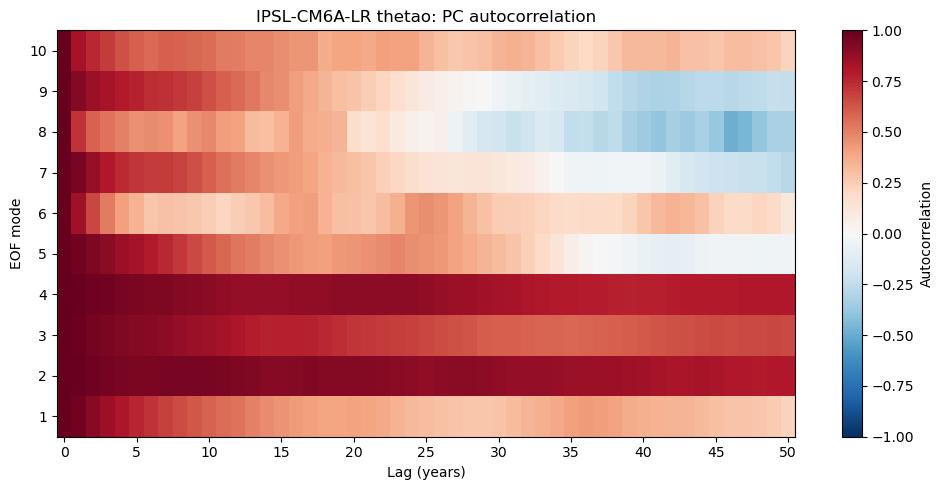

In [11]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# LOAD DATA
# -------------------------------------------------
MODEL = "IPSL-CM6A-LR"
VAR   = "thetao"

ds = xr.open_dataset(
    f"/data/users/frekle/AMOC_analysis/Lag-1_autocorrelation/lag1_autocorr_{MODEL}_{VAR}_26N_45N.nc"
)

acf_pc = ds["acf_pc"]   # (mode, lag)
lags   = ds["lag"].values
modes  = ds["mode"].values

# -------------------------------------------------
# PLOT: PC ACF HEATMAP
# -------------------------------------------------
plt.figure(figsize=(10, 5))

im = plt.imshow(
    acf_pc,
    aspect="auto",
    origin="lower",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)

plt.colorbar(im, label="Autocorrelation")
plt.xlabel("Lag (years)")
plt.ylabel("EOF mode")
plt.title(f"{MODEL} {VAR}: PC autocorrelation")

plt.xticks(np.arange(0, len(lags), 5), lags[::5])
plt.yticks(np.arange(len(modes)), modes)

plt.tight_layout()
plt.show()


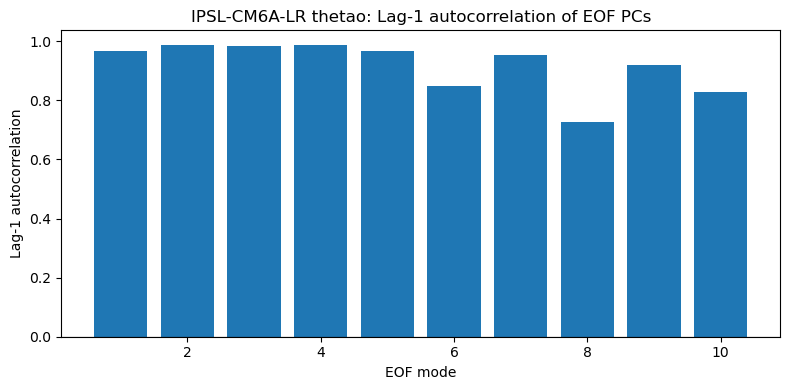

In [12]:
# -------------------------------------------------
# PLOT: LAG-1 AUTOCORRELATION PER MODE
# -------------------------------------------------
lag1_pc = ds["lag1_pc"].values

plt.figure(figsize=(8, 4))

plt.bar(modes, lag1_pc)
plt.axhline(0, color="k", linewidth=0.8)

plt.xlabel("EOF mode")
plt.ylabel("Lag-1 autocorrelation")
plt.title(f"{MODEL} {VAR}: Lag-1 autocorrelation of EOF PCs")

plt.tight_layout()
plt.show()




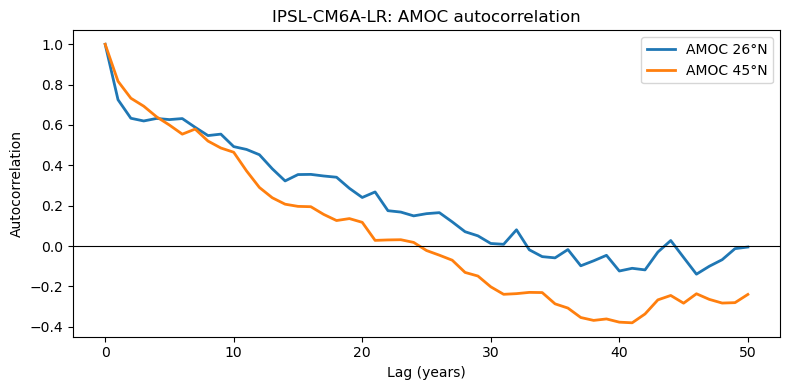

In [13]:
# -------------------------------------------------
# PLOT: AMOC AUTOCORRELATION
# -------------------------------------------------
acf_26 = ds["acf_amoc_26N"].values
acf_45 = ds["acf_amoc_45N"].values

plt.figure(figsize=(8, 4))

plt.plot(lags, acf_26, label="AMOC 26°N", lw=2)
plt.plot(lags, acf_45, label="AMOC 45°N", lw=2)

plt.axhline(0, color="k", linewidth=0.8)
plt.xlabel("Lag (years)")
plt.ylabel("Autocorrelation")
plt.title(f"{MODEL}: AMOC autocorrelation")

plt.legend()
plt.tight_layout()
plt.show()


In [14]:
#!/usr/bin/env python3
# ============================================================
# SLIDING-WINDOW LAG-1 AUTOCORRELATION
# For AMOC (26N, 45N) and EOF PCs
#
# Compatible with:
#   • EOF_latdepth_* files
#   • AMOC_<MODEL>.nc
#
# Purpose:
#   Diagnose temporal evolution of system stability
# ============================================================

import numpy as np
import xarray as xr
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# USER CONFIG
# ============================================================

MODEL = "IPSL-CM6A-LR"          # CESM2, MPI-ESM1-2-LR, IPSL-CM6A-LR, EC-Earth3
VAR   = "thetao"

EOF_FILE = (
    f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
    f"EOF_latdepth_{VAR}_W30p0.nc"
)

AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

WINDOW = 40        # years (30–50 is typical)
STEP   = 1         # years
MODES_TO_USE = [2, 3, 4, 5]   # PC indices (0-based!)

USE_ENSEMBLE_MEAN = True

# ============================================================
# UTILITIES
# ============================================================

def corr_pearson(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 3:
        return np.nan
    a = a[mask] - a[mask].mean()
    b = b[mask] - b[mask].mean()
    return float(np.dot(a, b) / np.sqrt(np.dot(a, a) * np.dot(b, b)))

def lag1_autocorr(x):
    return corr_pearson(x[:-1], x[1:])

# ============================================================
# LOAD EOF PCs
# ============================================================

print("\n▶ Loading EOF PCs")
ds_eof = xr.open_dataset(EOF_FILE)

PC = ds_eof["PC"]   # (member, time, mode)

if USE_ENSEMBLE_MEAN:
    PC = PC.mean("member")

time = PC["time"].values
ntime = len(time)

# ============================================================
# LOAD AMOC
# ============================================================

print("▶ Loading AMOC")
ds_amoc = xr.open_dataset(AMOC_FILE)

amoc26 = ds_amoc["AMOC_26N_ensmean"].values
amoc45 = ds_amoc["AMOC_45N_ensmean"].values

# ============================================================
# SLIDING WINDOW SETUP
# ============================================================

half = WINDOW // 2
centers = np.arange(half, ntime - half, STEP)
years = time[centers]

# Storage
lag1_pc   = np.full((len(MODES_TO_USE), len(centers)), np.nan)
lag1_26   = np.full(len(centers), np.nan)
lag1_45   = np.full(len(centers), np.nan)

print(f"\n▶ Sliding window: {WINDOW} years")
print(f"▶ Number of windows: {len(centers)}")

# ============================================================
# COMPUTE SLIDING-WINDOW LAG-1
# ============================================================

for i, c in enumerate(centers):
    t0 = c - half
    t1 = c + half

    # AMOC
    lag1_26[i] = lag1_autocorr(amoc26[t0:t1])
    lag1_45[i] = lag1_autocorr(amoc45[t0:t1])

    # PCs
    for j, m in enumerate(MODES_TO_USE):
        pc = PC.isel(mode=m).values[t0:t1]
        lag1_pc[j, i] = lag1_autocorr(pc)

print("✓ Sliding-window computation done")

# ============================================================
# SAVE OUTPUT
# ============================================================

OUTFILE = (
    f"/data/users/frekle/AMOC_analysis/Lag-1_autocorrelation/"
    f"sliding_lag1_{MODEL}_{VAR}_Window{WINDOW}.nc"
)

xr.Dataset(
    {
        "lag1_pc": (("mode", "time"), lag1_pc),
        "lag1_amoc_26N": (("time",), lag1_26),
        "lag1_amoc_45N": (("time",), lag1_45),
    },
    coords={
        "time": years,
        "mode": [m + 1 for m in MODES_TO_USE],
    },
    attrs={
        "MODEL": MODEL,
        "VAR": VAR,
        "WINDOW_YEARS": WINDOW,
        "NOTE": "Sliding-window lag-1 autocorrelation (critical slowing down diagnostic)",
    }
).to_netcdf(OUTFILE)

print("\n✓ Saved to:", OUTFILE)
print("✅ DONE")



▶ Loading EOF PCs
▶ Loading AMOC

▶ Sliding window: 40 years
▶ Number of windows: 125
✓ Sliding-window computation done

✓ Saved to: /data/users/frekle/AMOC_analysis/Lag-1_autocorrelation/sliding_lag1_IPSL-CM6A-LR_thetao_Window40.nc
✅ DONE


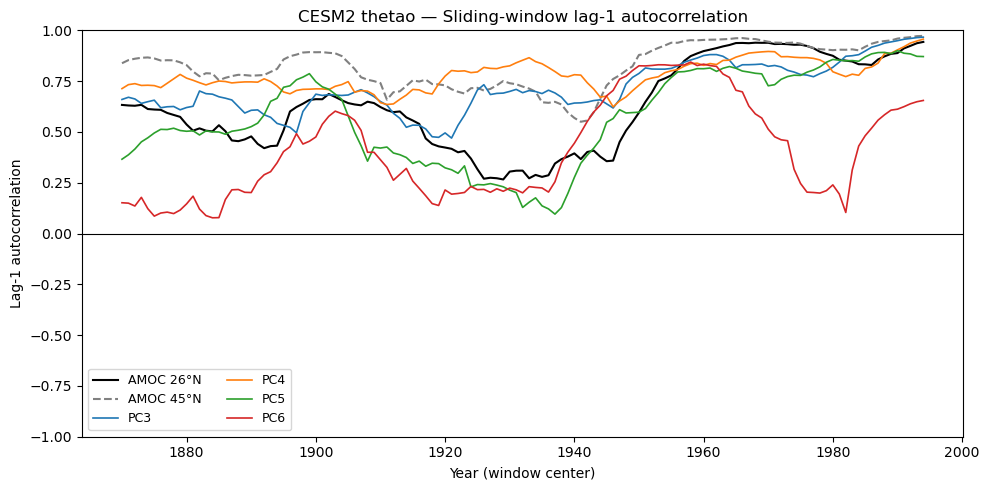

In [10]:
import xarray as xr
import matplotlib.pyplot as plt

MODEL = "CESM2"
VAR   = "thetao"
WINDOW = 40

ds = xr.open_dataset(
    f"/data/users/frekle/AMOC_analysis/Lag-1_autocorrelation/sliding_lag1_{MODEL}_{VAR}_Window{WINDOW}.nc"
)

# --- FIX HERE ---
time = ds["time"].dt.year.values
# ----------------

lag1_26 = ds["lag1_amoc_26N"].values
lag1_45 = ds["lag1_amoc_45N"].values
lag1_pc = ds["lag1_pc"].values
modes   = ds["mode"].values

plt.figure(figsize=(10, 5))

plt.plot(time, lag1_26, color="black", label="AMOC 26°N", lw=1.5)
plt.plot(time, lag1_45, color="gray", linestyle="--", label="AMOC 45°N", lw=1.5)

for i, m in enumerate(modes):
    plt.plot(time, lag1_pc[i], lw=1.2, label=f"PC{m}")

plt.axhline(0, color="k", lw=0.8)
plt.ylim(-1, 1)

plt.xlabel("Year (window center)")
plt.ylabel("Lag-1 autocorrelation")
plt.title(f"{MODEL} {VAR} — Sliding-window lag-1 autocorrelation")

plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


In [1]:
#!/usr/bin/env python3
# ============================================================
# PC–AMOC LAG MATRIX (LAT–DEPTH EOF VERSION)
#
# Computes lagged correlations between:
#   • EOF PCs (ensemble mean)
#   • AMOC at 26°N and 45°N
#
# Compatible with:
#   • EOF_latdepth_<VAR>_<lon>.nc
#   • AMOC_<MODEL>.nc
# ============================================================

import xarray as xr
import numpy as np

# ============================================================
# CONFIG
# ============================================================

MODEL = "CESM2"
VAR   = "thetao"
LONG = "W30"

EOF_FILE = (
    f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
    f"EOF_latdepth_{VAR}_{LONG}p0.nc"
)

AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

MAX_LAG = 50
modes_to_use = slice(None)   # or e.g. slice(0, 5)

# ============================================================
# LOAD EOF / PC DATA
# ============================================================

print("▶ Loading EOF dataset")
ds_eof = xr.open_dataset(EOF_FILE)

PC = ds_eof["PC"]   # (member, time, mode)

if "member" not in PC.dims:
    print("⚠️ No member dim → assuming single member")
    PC = PC.expand_dims("member")

ntime  = PC.sizes["time"]
nmodes = PC.sizes["mode"]

print(f"Time steps: {ntime}")
print(f"Modes:      {nmodes}")

# Ensemble-mean PCs
PC_mean = PC.mean("member").isel(mode=modes_to_use)   # (time, mode)

# ============================================================
# LOAD AMOC DATA
# ============================================================

print("▶ Loading AMOC")
ds_amoc = xr.open_dataset(AMOC_FILE)

amoc26 = ds_amoc["AMOC_26N_ensmean"].values
amoc45 = ds_amoc["AMOC_45N_ensmean"].values

if len(amoc26) != ntime:
    raise ValueError("❌ Time mismatch between PC and AMOC")

print("AMOC length validated ✔")

# ============================================================
# PEARSON CORRELATION
# ============================================================

def corr_pearson(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 3:
        return np.nan
    a = a[mask] - a[mask].mean()
    b = b[mask] - b[mask].mean()
    return float(np.dot(a, b) / np.sqrt(np.dot(a, a) * np.dot(b, b)))

# ============================================================
# BUILD LAG MATRICES
# ============================================================

lags = np.arange(MAX_LAG + 1)
lag_matrix_26 = np.zeros((PC_mean.sizes["mode"], MAX_LAG + 1))
lag_matrix_45 = np.zeros((PC_mean.sizes["mode"], MAX_LAG + 1))

print("\n▶ Computing PC–AMOC lag correlations")

for m in range(PC_mean.sizes["mode"]):
    pc = PC_mean.isel(mode=m).values

    for L in lags:
        lag_matrix_26[m, L] = corr_pearson(pc[:-L or None], amoc26[L:])
        lag_matrix_45[m, L] = corr_pearson(pc[:-L or None], amoc45[L:])

print("✓ Done")

# ============================================================
# SAVE OUTPUT
# ============================================================

OUTFILE = (
    f"/data/users/frekle/AMOC_analysis/Lag_plots/CESM2/Lat_depth/Figures/"
    f"lag_matrix_PC_AMOC_{MODEL}_{VAR}_latdepth_{LONG}.nc"
)

xr.Dataset(
    {
        "lagcorr_AMOC_26N": (("mode", "lag"), lag_matrix_26),
        "lagcorr_AMOC_45N": (("mode", "lag"), lag_matrix_45),
    },
    coords={
        "mode": PC_mean["mode"],
        "lag": lags,
    },
    attrs={
        "MODEL": MODEL,
        "VAR": VAR,
        "EOF_TYPE": "lat-depth",
        "NOTE": "Lagged correlation between EOF PCs and AMOC ensemble mean",
    }
).to_netcdf(OUTFILE)

print("\n✓ Saved to:", OUTFILE)
print("✅ DONE")


▶ Loading EOF dataset


/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'cartopy_utils' from partially initialized module 'metpy.plots' (most likely due to a circular import) (/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/metpy/plots/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


Time steps: 165
Modes:      10
▶ Loading AMOC
AMOC length validated ✔

▶ Computing PC–AMOC lag correlations
✓ Done

✓ Saved to: /data/users/frekle/AMOC_analysis/Lag_plots/CESM2/Lat_depth/Figures/lag_matrix_PC_AMOC_CESM2_thetao_latdepth_W30.nc
✅ DONE


/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'cartopy_utils' from partially initialized module 'metpy.plots' (most likely due to a circular import) (/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/metpy/plots/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


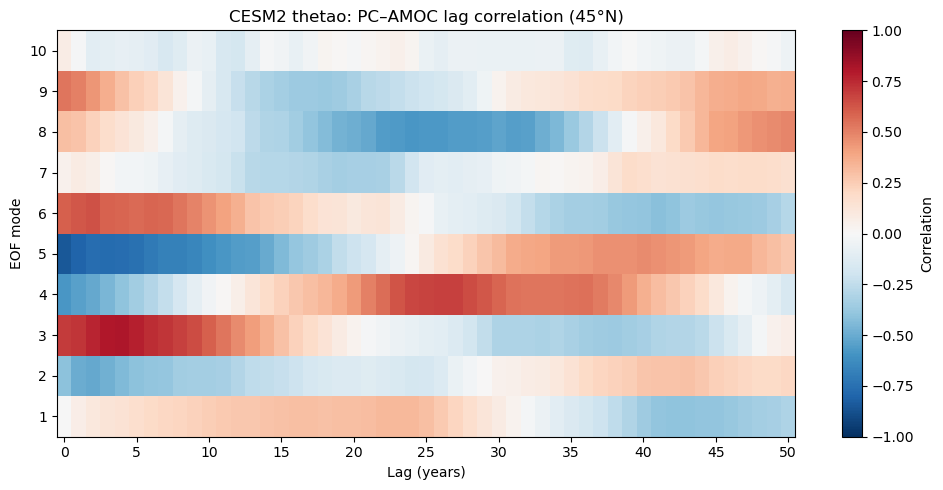

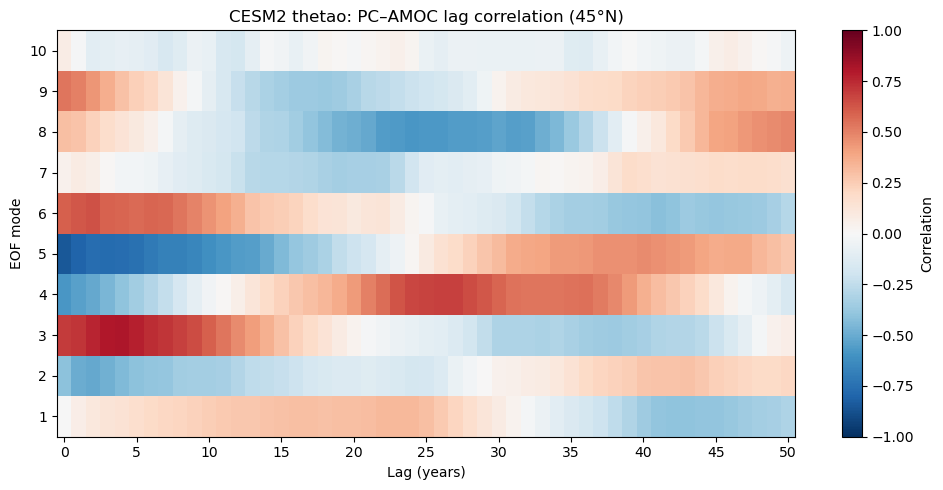

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

MODEL = "CESM2"
VAR   = "thetao"

ds = xr.open_dataset(
    f"/data/users/frekle/AMOC_analysis/"
    f"lag_matrix_PC_AMOC_{MODEL}_{VAR}_latdepth.nc"
)

lag26 = ds["lagcorr_AMOC_26N"]   # (mode, lag)
lag45 = ds["lagcorr_AMOC_45N"]

lags  = ds["lag"].values
modes = ds["mode"].values

plt.figure(figsize=(10, 5))

im = plt.imshow(
    lag45,
    aspect="auto",
    origin="lower",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)

plt.colorbar(im, label="Correlation")
plt.xlabel("Lag (years)")
plt.ylabel("EOF mode")

plt.title(f"{MODEL} {VAR}: PC–AMOC lag correlation (45°N)")

plt.xticks(np.arange(0, len(lags), 5), lags[::5])
plt.yticks(np.arange(len(modes)), modes)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

im = plt.imshow(
    lag45,
    aspect="auto",
    origin="lower",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)

plt.colorbar(im, label="Correlation")
plt.xlabel("Lag (years)")
plt.ylabel("EOF mode")

plt.title(f"{MODEL} {VAR}: PC–AMOC lag correlation (45°N)")

plt.xticks(np.arange(0, len(lags), 5), lags[::5])
plt.yticks(np.arange(len(modes)), modes)

plt.tight_layout()
plt.show()




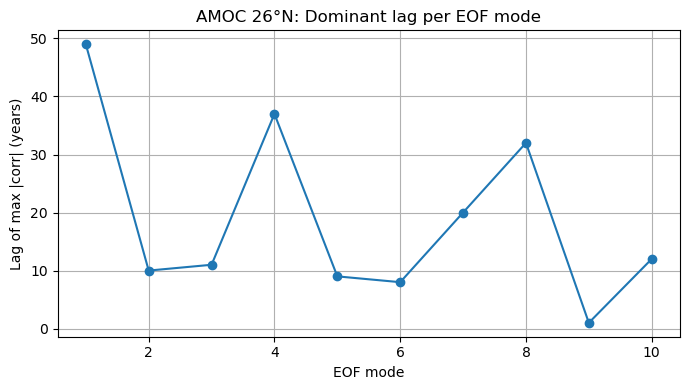

In [5]:
best_lag_26 = lags[np.nanargmax(np.abs(lag26), axis=1)]

plt.figure(figsize=(7, 4))
plt.plot(modes, best_lag_26, marker="o")
plt.xlabel("EOF mode")
plt.ylabel("Lag of max |corr| (years)")
plt.title("AMOC 26°N: Dominant lag per EOF mode")
plt.grid(True)
plt.tight_layout()
plt.show()


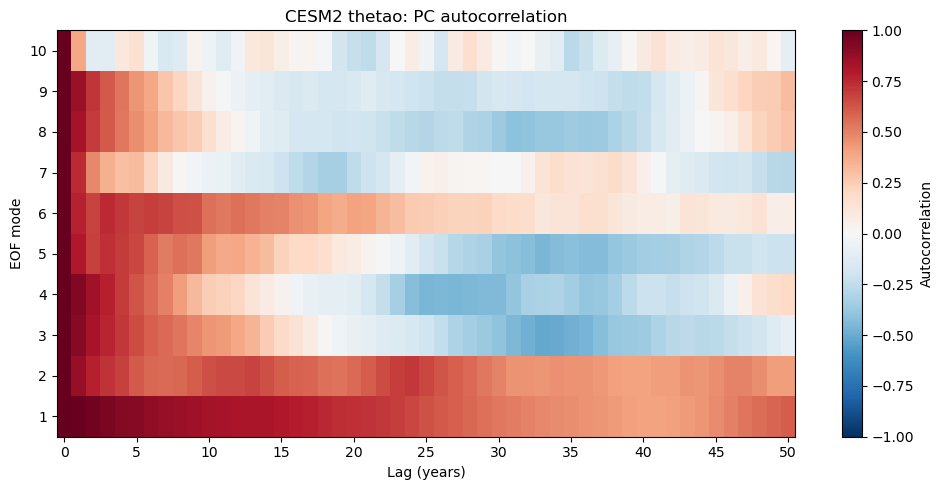

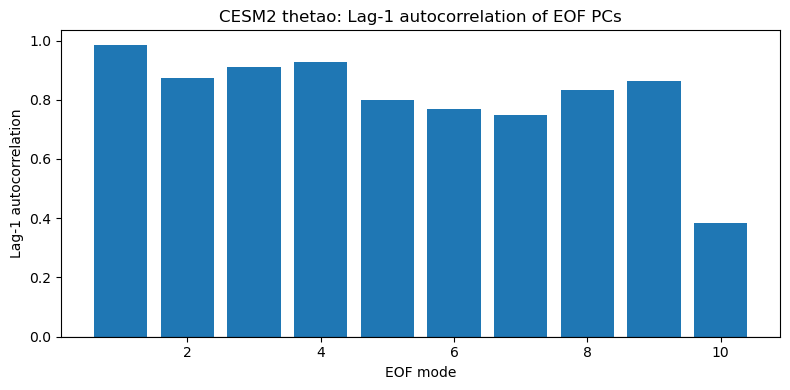

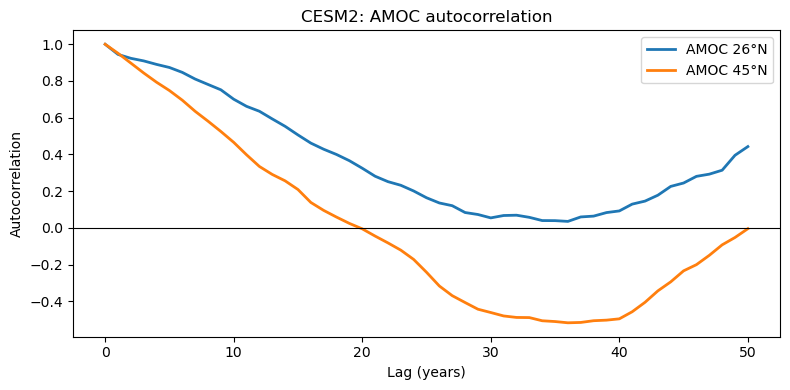

In [7]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# LOAD DATA
# -------------------------------------------------
MODEL = "CESM2"
VAR   = "thetao"

ds = xr.open_dataset(
    f"/data/users/frekle/AMOC_analysis/Lag-1_autocorrelation/lag1_autocorr_{MODEL}_{VAR}_26N_45N.nc"
)

acf_pc = ds["acf_pc"]   # (mode, lag)
lags   = ds["lag"].values
modes  = ds["mode"].values

# -------------------------------------------------
# PLOT: PC ACF HEATMAP
# -------------------------------------------------
plt.figure(figsize=(10, 5))

im = plt.imshow(
    acf_pc,
    aspect="auto",
    origin="lower",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)

plt.colorbar(im, label="Autocorrelation")
plt.xlabel("Lag (years)")
plt.ylabel("EOF mode")
plt.title(f"{MODEL} {VAR}: PC autocorrelation")

plt.xticks(np.arange(0, len(lags), 5), lags[::5])
plt.yticks(np.arange(len(modes)), modes)

plt.tight_layout()
plt.show()

# -------------------------------------------------
# PLOT: LAG-1 AUTOCORRELATION PER MODE
# -------------------------------------------------
lag1_pc = ds["lag1_pc"].values

plt.figure(figsize=(8, 4))

plt.bar(modes, lag1_pc)
plt.axhline(0, color="k", linewidth=0.8)

plt.xlabel("EOF mode")
plt.ylabel("Lag-1 autocorrelation")
plt.title(f"{MODEL} {VAR}: Lag-1 autocorrelation of EOF PCs")

plt.tight_layout()
plt.show()

# -------------------------------------------------
# PLOT: AMOC AUTOCORRELATION
# -------------------------------------------------
acf_26 = ds["acf_amoc_26N"].values
acf_45 = ds["acf_amoc_45N"].values

plt.figure(figsize=(8, 4))

plt.plot(lags, acf_26, label="AMOC 26°N", lw=2)
plt.plot(lags, acf_45, label="AMOC 45°N", lw=2)

plt.axhline(0, color="k", linewidth=0.8)
plt.xlabel("Lag (years)")
plt.ylabel("Autocorrelation")
plt.title(f"{MODEL}: AMOC autocorrelation")

plt.legend()
plt.tight_layout()
plt.show()

In [8]:
import xarray as xr
import numpy as np

MODEL="CESM2"
VAR="thetao"

ds = xr.open_dataset(
    f"/data/users/frekle/AMOC_analysis/Lag-1_autocorrelation/"
    f"lag1_autocorr_{MODEL}_{VAR}_26N_45N.nc"
)

lag1_pc = ds["lag1_pc"].values
modes   = ds["mode"].values

lag1_amoc26 = ds["acf_amoc_26N"].values[1]
lag1_amoc45 = ds["acf_amoc_45N"].values[1]

print("AMOC lag-1 26N:", lag1_amoc26)
print("AMOC lag-1 45N:", lag1_amoc45)

# Show top PCs closest to AMOC26 persistence
closest = np.argsort(np.abs(lag1_pc - lag1_amoc26))[:5]
print("Closest PCs to AMOC26 lag-1:")
for i in closest:
    print(f"PC{modes[i]}: lag1={lag1_pc[i]:+.3f}")


AMOC lag-1 26N: 0.9446989893913269
AMOC lag-1 45N: 0.9508126974105835
Closest PCs to AMOC26 lag-1:
PC4: lag1=+0.927
PC3: lag1=+0.911
PC1: lag1=+0.985
PC2: lag1=+0.873
PC9: lag1=+0.863


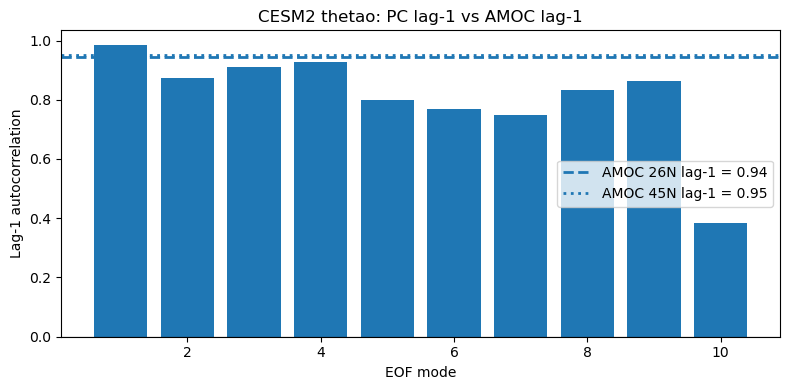

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(modes, lag1_pc)

plt.axhline(lag1_amoc26, linestyle="--", linewidth=2, label=f"AMOC 26N lag-1 = {lag1_amoc26:.2f}")
plt.axhline(lag1_amoc45, linestyle=":",  linewidth=2, label=f"AMOC 45N lag-1 = {lag1_amoc45:.2f}")
plt.axhline(0, color="k", linewidth=0.8)

plt.xlabel("EOF mode")
plt.ylabel("Lag-1 autocorrelation")
plt.title(f"{MODEL} {VAR}: PC lag-1 vs AMOC lag-1")
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_2283313/691548655.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", len(modes))


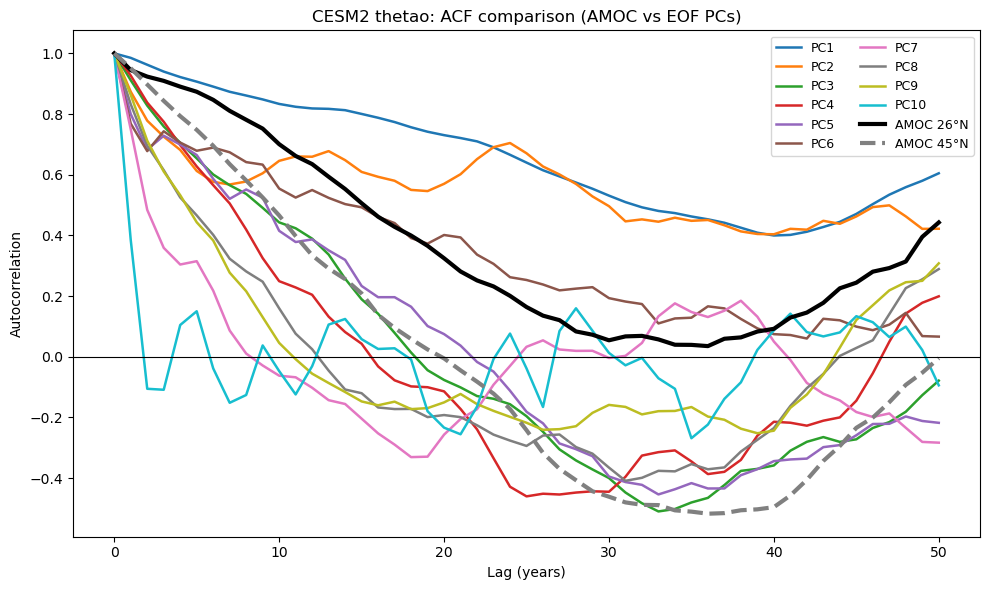

In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# -------------------------------------------------
# LOAD DATA
# -------------------------------------------------
MODEL = "CESM2"
VAR   = "thetao"

ds = xr.open_dataset(
    f"/data/users/frekle/AMOC_analysis/Lag-1_autocorrelation/"
    f"lag1_autocorr_{MODEL}_{VAR}_26N_45N.nc"
)

acf_pc = ds["acf_pc"].values        # (mode, lag)
acf_26 = ds["acf_amoc_26N"].values
acf_45 = ds["acf_amoc_45N"].values
lags   = ds["lag"].values
modes  = ds["mode"].values

# -------------------------------------------------
# PLOT
# -------------------------------------------------
plt.figure(figsize=(10, 6))

cmap = cm.get_cmap("tab10", len(modes))

for i, m in enumerate(modes):
    plt.plot(
        lags,
        acf_pc[i],
        color=cmap(i),
        linewidth=1.8,
        label=f"PC{m}"
    )

# AMOC reference
plt.plot(lags, acf_26, color="black", linewidth=3, label="AMOC 26°N")
plt.plot(lags, acf_45, color="gray",  linewidth=3, linestyle="--", label="AMOC 45°N")

plt.axhline(0, color="k", linewidth=0.8)
plt.xlabel("Lag (years)")
plt.ylabel("Autocorrelation")
plt.title(f"{MODEL} {VAR}: ACF comparison (AMOC vs EOF PCs)")

plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


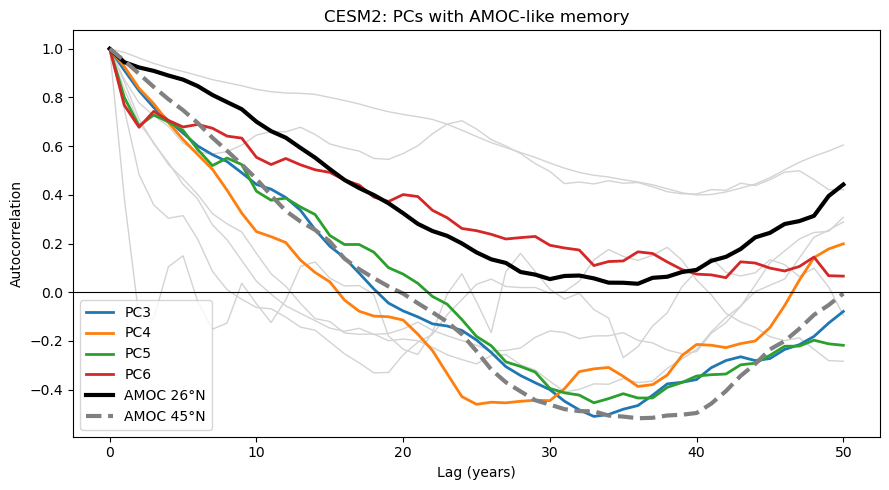

In [5]:
PCS_TO_HIGHLIGHT = [2, 3, 4, 5]  # zero-based indices

plt.figure(figsize=(9, 5))

# Background PCs
for i in range(acf_pc.shape[0]):
    plt.plot(lags, acf_pc[i], color="lightgray", linewidth=1)

# Highlighted PCs
for i in PCS_TO_HIGHLIGHT:
    plt.plot(lags, acf_pc[i], linewidth=2, label=f"PC{modes[i]}")

# AMOC
plt.plot(lags, acf_26, color="black", linewidth=3, label="AMOC 26°N")
plt.plot(lags, acf_45, color="gray",  linewidth=3, linestyle="--", label="AMOC 45°N")

plt.axhline(0, color="k", linewidth=0.8)
plt.xlabel("Lag (years)")
plt.ylabel("Autocorrelation")
plt.title(f"{MODEL}: PCs with AMOC-like memory")

plt.legend()
plt.tight_layout()
plt.show()
